# 02 — Distance Metrics & Distance Kernels

**Vignette index:** | [`01` GKMKernel basics](01_basic_kernel_matrix.ipynb) | `**02**` Distance metrics & kernels | [`03` SVM with kernel](03_svc_with_kernel.ipynb) | [`04` Clustering](04_clustering_sequences.ipynb) | [`05` Long sequence scoring](05_score_long_sequence.ipynb) | [`06` Weighted (WGKM) kernel](06_weighted_kernel.ipynb) | [`07` Transforms & comparison](07_transform_and_comparison.ipynb) | [`08` Windowed 3D tensors](08_windowed_3d_tensors.ipynb) | [`09` Spectrum encoder & NB](09_spectrum_encoder_and_differential.ipynb) | [`10` Gappy encoder](10_gappy_encoder.ipynb) | [`11` Mismatch encoder](11_mismatch_encoder.ipynb) | [`12` Shuffler & chunker](12_shuffler_and_chunker.ipynb)

`kmer.distance` provides pairwise sequence metrics and a `DistanceKernel` that turns any distance into a kernel.

**Optional backends (strongly recommended for speed):**
- `rapidfuzz` — 10-100x faster Hamming/Levenshtein.
- `parasail` — SIMD-accelerated NW/SW alignment.

```bash
pip install rapidfuzz parasail
```

All metrics implement `BaseDistance` with `__call__`, `cdist`, and `pdist`. `DistanceKernel` wraps any `BaseDistance` with a post-transform (RBF, Laplacian, Cauchy, etc.) to produce a PSD Gram matrix suitable for `SVC(kernel='precomputed')`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from kmer.distance import Hamming, Levenshtein, NeedlemanWunsch, SmithWaterman, DistanceKernel

import importlib.util
print(f"rapidfuzz available: {importlib.util.find_spec('rapidfuzz') is not None}")
print(f"parasail available: {importlib.util.find_spec('parasail') is not None}")

rapidfuzz available: True
parasail available: True


## Part I — Distance Metrics

## 1. Hamming distance (equal-length only)

In [2]:
print('ACGT vs ACGA:', Hamming()('ACGT', 'ACGA'))
print('ACGT vs TGCA:', Hamming()('ACGT', 'TGCA'))

ACGT vs ACGA: 1.0
ACGT vs TGCA: 4.0


## 2. Levenshtein distance

In [3]:
print('ACGT vs ACGTA (insertion):', Levenshtein()('ACGT', 'ACGTA'))
print('ACGT vs ACG  (deletion):', Levenshtein()('ACGT', 'ACG'))
print('ACGT vs ACGA (substitution):', Levenshtein()('ACGT', 'ACGA'))

ACGT vs ACGTA (insertion): 1.0
ACGT vs ACG  (deletion): 1.0
ACGT vs ACGA (substitution): 1.0


## 3. Pairwise distance matrix (heatmap)

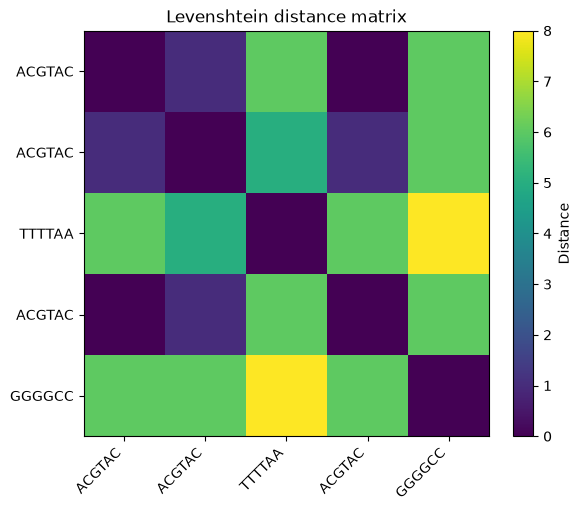

In [4]:
seqs = ['ACGTACGT', 'ACGTACGA', 'TTTTAAAA', 'ACGTACGT', 'GGGGCCCC']
D = Levenshtein().cdist(seqs)

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
im = ax.imshow(D, cmap='viridis')
ax.set_xticks(range(len(seqs)))
ax.set_yticks(range(len(seqs)))
ax.set_xticklabels([s[:6] for s in seqs], rotation=45, ha='right')
ax.set_yticklabels([s[:6] for s in seqs])
ax.set_title('Levenshtein distance matrix')
plt.colorbar(im, ax=ax, label='Distance')
plt.show()

## 4. Needleman-Wunsch (global alignment score)

In [5]:
nw = NeedlemanWunsch(match=1, mismatch=-1, gap=-1)
print('ACGT vs ACGT:', nw('ACGT', 'ACGT'))
print('ACGT vs ACG:', nw('ACGT', 'ACG'))
print('ACGT vs AAAA:', nw('ACGT', 'AAAA'))

ACGT vs ACGT: 4.0
ACGT vs ACG: 2.0
ACGT vs AAAA: -2.0


## 5. Smith-Waterman (local alignment score)

In [6]:
sw = SmithWaterman(match=1, mismatch=-1, gap=-1)
print('ACGT vs TTACGTTT:', sw('ACGT', 'TTACGTTT'))

ACGT vs TTACGTTT: 4.0


## 6. Custom substitution matrix (NUC4.4)

In [7]:
nw = NeedlemanWunsch(substitution_matrix='NUC4.4', gap=-4)
print('ACGT vs ACGT (NUC4.4):', nw('ACGT', 'ACGT'))

ACGT vs ACGT (NUC4.4): 20.0


## 7. NW score matrix (heatmap)

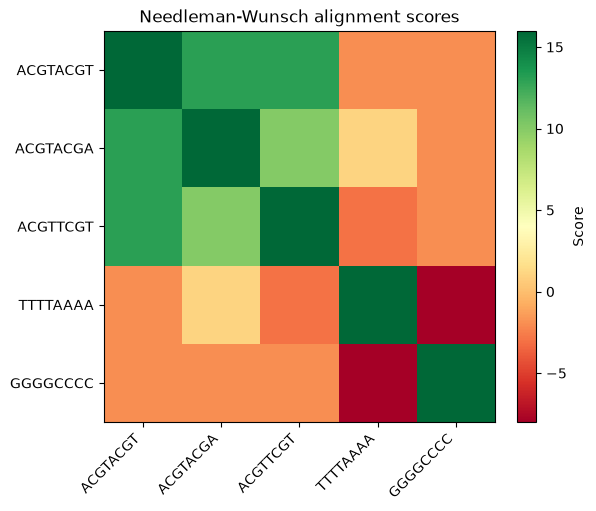

In [8]:
seqs = ['ACGTACGT', 'ACGTACGA', 'ACGTTCGT', 'TTTTAAAA', 'GGGGCCCC']
nw = NeedlemanWunsch(match=2, mismatch=-1, gap=-1)
S = nw.cdist(seqs)

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
im = ax.imshow(S, cmap='RdYlGn')
ax.set_xticks(range(len(seqs)))
ax.set_yticks(range(len(seqs)))
ax.set_xticklabels(seqs, rotation=45, ha='right')
ax.set_yticklabels(seqs)
ax.set_title('Needleman-Wunsch alignment scores')
plt.colorbar(im, ax=ax, label='Score')
plt.show()

---

## Part II — Distance Kernels

`DistanceKernel` wraps any `BaseDistance` with a post-transform to produce a kernel matrix.

## 8. RBF kernel on Levenshtein distance

In [9]:
seqs = ['ACGT', 'ACGTA', 'TTTT', 'ACGTACGT', 'GCGCGCGC']
kern = DistanceKernel(Levenshtein(), transform='rbf', gamma=0.1)
K = kern.kernel_matrix(seqs)
print("Gram matrix (rounded):")
print(np.round(K, 3))

Gram matrix (rounded):
[[1.    0.905 0.407 0.202 0.027]
 [0.905 1.    0.202 0.407 0.027]
 [0.407 0.202 1.    0.027 0.002]
 [0.202 0.407 0.027 1.    0.202]
 [0.027 0.027 0.002 0.202 1.   ]]


## 9. Verify PSD property

RBF, Laplacian, and Cauchy transforms on proper metrics should produce PSD Gram matrices.

In [10]:
for transform in ['rbf', 'laplacian', 'cauchy']:
    kern = DistanceKernel(Levenshtein(), transform=transform, gamma=0.1)
    K = kern.kernel_matrix(seqs)
    eigvals = np.linalg.eigvalsh(K)
    print(f"{transform:10s}: min eigenvalue = {eigvals.min():.6e} (PSD: {eigvals.min() >= -1e-10})")

rbf       : min eigenvalue = 4.873783e-02 (PSD: True)
laplacian : min eigenvalue = 7.972503e-02 (PSD: True)
cauchy    : min eigenvalue = 6.151944e-02 (PSD: True)


## 10. Available transforms

In [11]:
for transform in ['linear', 'rbf', 'poly', 'sigmoid', 'laplacian', 'exponential', 'exponential_clipped', 'cauchy']:
    kern = DistanceKernel(Hamming(), transform=transform, gamma=1.0)
    val = kern('ACGT', 'ACGA')
    print(f"{transform:22s}: K(ACGT, ACGA) = {val:.4f}")

linear                : K(ACGT, ACGA) = -1.0000
rbf                   : K(ACGT, ACGA) = 0.3679
poly                  : K(ACGT, ACGA) = -1.0000
sigmoid               : K(ACGT, ACGA) = -0.7616
laplacian             : K(ACGT, ACGA) = 0.3679
exponential           : K(ACGT, ACGA) = 0.3679
exponential_clipped   : K(ACGT, ACGA) = 0.3679
cauchy                : K(ACGT, ACGA) = 0.5000


## 11. Train a KernelSVM

**See also:** [03_svc_with_kernel.ipynb](03_svc_with_kernel.ipynb) for more on training SVMs with kernels.

In [12]:
from kmer.models import KernelSVM
np.random.seed(0)
positives = ['ACGTACGT' + 'ACGT' * np.random.randint(0, 3) for _ in range(20)]
negatives = ['ATATATAT' + 'ATAT' * np.random.randint(0, 3) for _ in range(20)]
all_seqs = positives + negatives
y = np.array([1]*20 + [0]*20)

kern = DistanceKernel(Levenshtein(), transform='rbf', gamma=0.05)
clf = KernelSVM(kern, C=1.0)
clf.fit(all_seqs, y)
acc = (clf.predict(all_seqs) == y).mean()
print(f"Train accuracy: {acc:.2f}")

Train accuracy: 1.00
